# modify fits header

## 필요한 모듈

이 프로젝트를 위해서는 아래의 모듈이 필요하다. 

> numpy, pandas, matplotlib, astropy, version_information

### 모듈 설치

1. 콘솔 창에서 모듈을 설치할 때는 아래와 같은 형식으로 입력하면 된다.

>pip install module_name==version

>conda install module_name==version

2. 주피터 노트북(코랩 포함)에 설치 할 때는 아래의 셀을 실행해서 실행되지 않은 모듈을 설치할 수 있다. (pip 기준) 만약 아나콘다 환경을 사용한다면 7행을 콘다 설치 명령어에 맞게 수정하면 된다.

In [1]:
import importlib, sys, subprocess
packages = "numpy, pandas, matplotlib, scipy, astropy, photutils, ccdproc, version_information" # required modules
pkgs = packages.split(", ")
for pkg in pkgs :
    if not importlib.util.find_spec(pkg):
        print(f"**** module {pkg} is not installed")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
    else: 
        print(f"**** module {pkg} is installed")

**** module numpy is installed
**** module pandas is installed
**** module matplotlib is installed
**** module scipy is installed
**** module astropy is installed
**** module photutils is installed
**** module ccdproc is installed
**** module version_information is installed


### 모듈 버전 확인

아래 셀을 실행하면 이 노트북을 실행한 파이썬 및 관련 모듈의 버전을 확인할 수 있다.

In [2]:
%load_ext version_information
import time
now = time.strftime("%Y-%m-%d %H:%M:%S (%Z = GMT%z)")
print(f"This notebook was generated at {now} ")

vv = %version_information {packages}
for i, pkg in enumerate(vv.packages):
    print(f"{i} {pkg[0]:10s} {pkg[1]:s}")

This notebook was generated at 2023-01-29 17:15:19 (대한민국 표준시 = GMT+0900) 
0 Python     3.9.7 64bit [MSC v.1916 64 bit (AMD64)]
1 IPython    7.31.1
2 OS         Windows 10 10.0.22621 SP0
3 numpy      1.21.5
4 pandas     1.4.1
5 matplotlib 3.5.1
6 scipy      1.7.3
7 astropy    5.0
8 photutils  1.5.0
9 ccdproc    2.3.1
10 version_information 1.0.4


### import modules

In [13]:
from glob import glob
from pathlib import Path, PosixPath, WindowsPath
import os
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.stats import sigma_clip
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.nddata import CCDData, Cutout2D
from astropy.stats import mad_std
from astropy.table import Table
from astropy.time import Time
from astropy.visualization import ImageNormalize, ZScaleInterval
from astropy.wcs import WCS, Wcsprm
from ccdproc import combine, ccd_process, CCDData

import ysfitsutilpy as yfu
import ysphotutilpy as ypu
import ysvisutilpy as yvu

import astro_utilities
import Python_utilities

plt.rcParams.update({'figure.max_open_warning': 0})

In [14]:
#%%
BASEDIR = astro_utilities.base_dir

BASEDIRs = sorted(Python_utilities.getFullnameListOfsubDir(BASEDIR))
print ("BASEDIRs: {}".format(BASEDIRs))
print ("len(BASEDIRs): {}".format(len(BASEDIRs)))


BASEDIR = Path(BASEDIRs[4])
print ("Starting...\n{}".format(BASEDIR))

BASEDIR = Path(BASEDIR)

MASTERDIR = BASEDIR / astro_utilities.master_dir

if not MASTERDIR.exists():
    os.makedirs("{}".format(str(MASTERDIR)))
    print("{} is created...".format(str(MASTERDIR)))

BASEDIRs: ['R:\\CCD_obs\\RnE_2022\\RiLA600_STX-16803_2bin\\KLEOPATRA_Light_-_2022-10-23_-_RiLA600_STX-16803_-_2bin/', 'R:\\CCD_obs\\RnE_2022\\RiLA600_STX-16803_2bin\\KLEOPATRA_Light_-_2022-10-24_-_RiLA600_STX-16803_-_2bin/', 'R:\\CCD_obs\\RnE_2022\\RiLA600_STX-16803_2bin\\KLEOPATRA_Light_-_2022-10-25_-_RiLA600_STX-16803_-_2bin/', 'R:\\CCD_obs\\RnE_2022\\RiLA600_STX-16803_2bin\\KLEOPATRA_Light_-_2022-10-27_-_RiLA600_STX-16803_-_2bin/', 'R:\\CCD_obs\\RnE_2022\\RiLA600_STX-16803_2bin\\KLEOPATRA_Light_-_2022-11-02_-_RiLA600_STX-16803_-_2bin/', 'R:\\CCD_obs\\RnE_2022\\RiLA600_STX-16803_2bin\\KLEOPATRA_Light_-_2022-11-04_-_RiLA600_STX-16803_-_2bin/', 'R:\\CCD_obs\\RnE_2022\\RiLA600_STX-16803_2bin\\KLEOPATRA_Light_-_2022-11-17_-_RiLA600_STX-16803_-_2bin/', 'R:\\CCD_obs\\RnE_2022\\RiLA600_STX-16803_2bin\\LANDOLT-114670_Light_-_2022-10-23_-_RiLA600_STX-16803_-_2bin/', 'R:\\CCD_obs\\RnE_2022\\RiLA600_STX-16803_2bin\\LANDOLT-114670_Light_-_2022-10-24_-_RiLA600_STX-16803_-_2bin/', 'R:\\CCD_obs\\Rn

In [20]:

from datetime import datetime
summary = yfu.make_summary(BASEDIR/"*.fit*")
#print(summary)
print("len(summary):", len(summary))
print("summary:", summary)
#print(summary["file"][0])

now = datetime.now()
fpath = Path(f"summary_{now.strftime('%Y%m%d-%H%M%S')}.csv")
summary.to_csv(str(fpath))
if fpath.exists() :
    print(f"{str(fpath)} is created...")

All 31 keywords (guessed from R:\CCD_obs\RnE_2022\RiLA600_STX-16803_2bin\KLEOPATRA_Light_-_2022-11-02_-_RiLA600_STX-16803_-_2bin\-_Bias_-_2022-11-15-12-01-37_000sec_RiLA600_STX-16803_-19C_2bin.fit) will be loaded.


c:\users\kiehyun\downloads\ysfitsutilpy\ysfitsutilpy\filemgmt.py:298: UserWarning: Key EXTEND not found for R:\CCD_obs\RnE_2022\RiLA600_STX-16803_2bin\KLEOPATRA_Light_-_2022-11-02_-_RiLA600_STX-16803_-_2bin\-_Flat_B_2022-10-25-08-44-49_000sec_RiLA600_STX-16803_-25C_2bin.fit, filling with None.
  warn(str_keyerror_fill.format(k, str(item)))
c:\users\kiehyun\downloads\ysfitsutilpy\ysfitsutilpy\filemgmt.py:298: UserWarning: Key DATE-LOC not found for R:\CCD_obs\RnE_2022\RiLA600_STX-16803_2bin\KLEOPATRA_Light_-_2022-11-02_-_RiLA600_STX-16803_-_2bin\-_Flat_B_2022-10-25-08-44-49_000sec_RiLA600_STX-16803_-25C_2bin.fit, filling with None.
  warn(str_keyerror_fill.format(k, str(item)))
c:\users\kiehyun\downloads\ysfitsutilpy\ysfitsutilpy\filemgmt.py:298: UserWarning: Key FOCRATIO not found for R:\CCD_obs\RnE_2022\RiLA600_STX-16803_2bin\KLEOPATRA_Light_-_2022-11-02_-_RiLA600_STX-16803_-_2bin\-_Flat_B_2022-10-25-08-44-49_000sec_RiLA600_STX-16803_-25C_2bin.fit, filling with None.
  warn(str_keyerr

len(summary): 267
summary:                                                   file  filesize  SIMPLE  \
0    R:\CCD_obs\RnE_2022\RiLA600_STX-16803_2bin\KLE...   8392320    True   
1    R:\CCD_obs\RnE_2022\RiLA600_STX-16803_2bin\KLE...   8392320    True   
2    R:\CCD_obs\RnE_2022\RiLA600_STX-16803_2bin\KLE...   8392320    True   
3    R:\CCD_obs\RnE_2022\RiLA600_STX-16803_2bin\KLE...   8392320    True   
4    R:\CCD_obs\RnE_2022\RiLA600_STX-16803_2bin\KLE...   8392320    True   
..                                                 ...       ...     ...   
262  R:\CCD_obs\RnE_2022\RiLA600_STX-16803_2bin\KLE...   8395200    True   
263  R:\CCD_obs\RnE_2022\RiLA600_STX-16803_2bin\KLE...   8395200    True   
264  R:\CCD_obs\RnE_2022\RiLA600_STX-16803_2bin\KLE...   8395200    True   
265  R:\CCD_obs\RnE_2022\RiLA600_STX-16803_2bin\KLE...   8395200    True   
266  R:\CCD_obs\RnE_2022\RiLA600_STX-16803_2bin\KLE...   8395200    True   

     BITPIX  NAXIS  NAXIS1  NAXIS2 EXTEND    BZERO IMAGETYP 

In [25]:
#help(yfu.filemgmt)
#help(yfu.hduutil)

Help on module ysfitsutilpy.hduutil in ysfitsutilpy:

NAME
    ysfitsutilpy.hduutil

FUNCTIONS
    CCDData_astype(ccd, dtype='float32', uncertainty_dtype=None, copy=True)
        Assign dtype to the CCDData object (numpy uses float64 default).
        
        Parameters
        ----------
        ccd : CCDData
            The ccd to be astyped.
        
        dtype : dtype-like
            The dtype to be applied to the data
        
        uncertainty_dtype : dtype-like
            The dtype to be applied to the uncertainty. Be default, use the same
            dtype as data (``uncertainty_dtype=dtype``).
        
        Example
        -------
        >>> from astropy.nddata import CCDData
        >>> import numpy as np
        >>> ccd = CCDData.read("image_unitygain001.fits", 0)
        >>> ccd.uncertainty = np.sqrt(ccd.data)
        >>> ccd = yfu.CCDData_astype(ccd, dtype='int16', uncertainty_dtype='float32')
    
    _has_header(ccdlike, extension=None, open_if_file=True)
   

In [26]:
df_light = summary.loc[summary["IMAGETYP"] == "LIGHT"].copy()
df_light = df_light.reset_index(drop=True)
#print("df_light:\n{}".format(df_light))

light_fits = df_light["file"]
print(type(light_fits))
print(len(light_fits))
print(light_fits)

<class 'pandas.core.series.Series'>
75
0     R:\CCD_obs\RnE_2022\RiLA600_STX-16803_2bin\KLE...
1     R:\CCD_obs\RnE_2022\RiLA600_STX-16803_2bin\KLE...
2     R:\CCD_obs\RnE_2022\RiLA600_STX-16803_2bin\KLE...
3     R:\CCD_obs\RnE_2022\RiLA600_STX-16803_2bin\KLE...
4     R:\CCD_obs\RnE_2022\RiLA600_STX-16803_2bin\KLE...
                            ...                        
70    R:\CCD_obs\RnE_2022\RiLA600_STX-16803_2bin\KLE...
71    R:\CCD_obs\RnE_2022\RiLA600_STX-16803_2bin\KLE...
72    R:\CCD_obs\RnE_2022\RiLA600_STX-16803_2bin\KLE...
73    R:\CCD_obs\RnE_2022\RiLA600_STX-16803_2bin\KLE...
74    R:\CCD_obs\RnE_2022\RiLA600_STX-16803_2bin\KLE...
Name: file, Length: 75, dtype: object


In [33]:
from astropy.io import fits

fpath1 = Path(light_fits[0])
fpath2 = Path(light_fits[5])
fpath3 = Path(light_fits[0])
fpath4 = Path(light_fits[3])
hdul1 = fits.open(str(fpath1))

hdul2 = yfu.load_ccd(str(fpath1))


In [34]:
#print(yfu._has_header(hdul1))
#print(yfu._parse_data_header(hdul1))
print(yfu._parse_data_header(hdul2))
set_ccd_attribute(hdul1, 'gain', value=2, unit='electron/adu')

(array([[15978, 14137, 14129, ..., 13030, 13401,  7591],
       [14103, 14091, 13986, ..., 13015, 13390,  7507],
       [13962, 14057, 14015, ..., 13149, 13209,  7554],
       ...,
       [13924, 13746, 13672, ..., 12509, 12861,  7346],
       [13688, 13984, 13926, ..., 12605, 12988,  7408],
       [14325, 13951, 14206, ..., 13025, 13239,  7403]], dtype=uint16), SIMPLE  =                    T / C# FITS                                        
BITPIX  =                   16 /                                                
NAXIS   =                    2 / Dimensionality                                 
NAXIS1  =                 2048 /                                                
NAXIS2  =                 2048 /                                                
EXTEND  =                    T / Extensions are permitted                       
BZERO   =                32768 /                                                
IMAGETYP= 'LIGHT'              / Type of exposure                   

In [35]:
def commentremove(
    path=None,
    additional_keys=None,
    extension=None,
    output=None,
    output_verify="fix",
    overwrite=False,
    verbose=True,
    close=True,
):
    """ Remove most comment keywords from the header.

    Paramters
    ---------
    additional_keys : list of regex str, optional
        Additional keys given by the user to be 'reset'. It must be in regex
        expression. Of course regex accepts just string, like 'NAXIS1'.

    output: str or Path
        The output file path.
    """
    # Define header keywords to be deleted in regex:
    re2remove = [
        "COMMENT",  # COMMENT
    ]
    # WCS[A-Z] captures, WCS[DIM, RFCAT, IMCAT, MATCH, NREF, TOL, SEP],
    # but not [IM]WCS, for example. These are likely to have been inserted
    # by WCS updating tools like astrometry.net or WCSlib/WCSTools. I
    # intentionally ignored IMWCS just for future reference.

    if additional_keys is not None:
        re2remove = re2remove + listify(additional_keys)

    # If following str is in comment, suggest it if verbose
    candidate_re = ["wcs", "axis", "axes", "coord", "distortion", "reference"]
    candidate_key = []

    hdul = fits.open(path)
    hdr = hdul[_parse_extension(extension)].header

    if verbose:
        print("Removed keywords: ", end="")

    for k in list(hdr.keys()):
        com = hdr.comments[k]
        deleted = False
        for re_i in re2remove:
            if re.match(re_i, k) is not None and not deleted:
                hdr.remove(k)
                deleted = True
                if verbose:
                    print(f"{k}", end=" ")
                continue
        if not deleted:
            for re_cand in candidate_re:
                if re.match(re_cand, com):
                    candidate_key.append(k)
    if verbose:
        print("\n")
        if len(candidate_key) != 0:
            print(f"\nFollowing keys may be related to WCS too:\n\t{candidate_key}")

    hdul[extension].header = hdr

    if output is not None:
        hdul.writeto(output, output_verify=output_verify, overwrite=overwrite)

    if close:
        hdul.close()
        return
    else:
        return hdul

ImportError: attempted relative import with no known parent package

In [30]:



print("hdul1[0].header", hdul1[0].header)
print("hdul1[0].header['INSTRUME']", hdul1[0].header['INSTRUME'])

if "INSTRUME" in hdul1[0].header :
    yfu.set_ccd_gain_rdnoise

True
hdul1[0].header SIMPLE  =                    T / C# FITS                                        BITPIX  =                   16 /                                                NAXIS   =                    2 / Dimensionality                                 NAXIS1  =                 2048 /                                                NAXIS2  =                 2048 /                                                EXTEND  =                    T / Extensions are permitted                       BZERO   =                32768 /                                                IMAGETYP= 'LIGHT'              / Type of exposure                               EXPOSURE=                240.0 / [s] Exposure duration                          EXPTIME =                240.0 / [s] Exposure duration                          DATE-LOC= '2022-11-02T19:08:14.386' / Time of observation (local)               DATE-OBS= '2022-11-02T10:08:14.386' / Time of observation (UTC)                 XBINNING=          

### BIAS

In [21]:
help(yfu.hduutil)
help(yfu.re)

Help on module ysfitsutilpy.hduutil in ysfitsutilpy:

NAME
    ysfitsutilpy.hduutil

FUNCTIONS
    CCDData_astype(ccd, dtype='float32', uncertainty_dtype=None, copy=True)
        Assign dtype to the CCDData object (numpy uses float64 default).
        
        Parameters
        ----------
        ccd : CCDData
            The ccd to be astyped.
        
        dtype : dtype-like
            The dtype to be applied to the data
        
        uncertainty_dtype : dtype-like
            The dtype to be applied to the uncertainty. Be default, use the same
            dtype as data (``uncertainty_dtype=dtype``).
        
        Example
        -------
        >>> from astropy.nddata import CCDData
        >>> import numpy as np
        >>> ccd = CCDData.read("image_unitygain001.fits", 0)
        >>> ccd.uncertainty = np.sqrt(ccd.data)
        >>> ccd = yfu.CCDData_astype(ccd, dtype='int16', uncertainty_dtype='float32')
    
    _has_header(ccdlike, extension=None, open_if_file=True)
   

In [47]:
bias_fits = summary[summary["IMAGETYP"] == "BIAS"]["file"]
bias_comb = yfu.group_combine(
                bias_fits.tolist(),
                type_key = ["IMAGETYP"],
                type_val = ["BIAS"],
                group_key = ["EXPTIME"],
                fmt = "master_bias.fits",  # output file name format
                outdir = MASTERDIR,  # output directory (will automatically be made if not exist)
                combine = "avg",
                verbose = True
            )

Group and combine by ['EXPTIME'] (total 1 groups)
* 1.0... (20 files)


ValueError: Currently chunked combine is not supporte T__T. Please try increasing memlimit to > 4.0e+09, or use combine='avg' than 'median'.

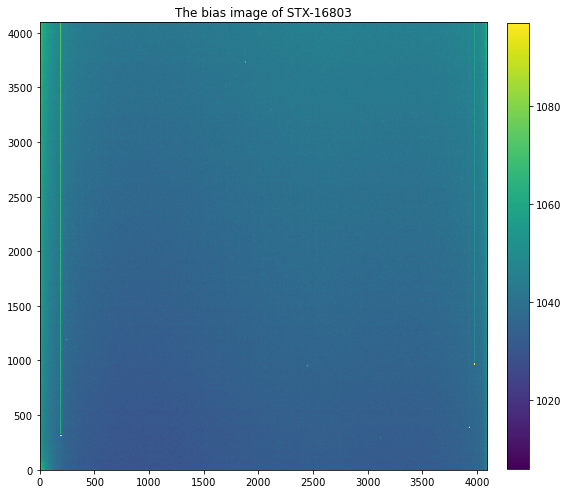

In [ ]:
from astropy.io import fits
hdul = fits.open(bias_fits[0])

fig, axs = plt.subplots(1, 1, figsize=(8, 8), sharex=False, sharey=False, gridspec_kw=None)
im = yvu.zimshow(axs, hdul[0].data)
axs.set_title('The bias image of STX-16803')
plt.colorbar(im, fraction=0.0455, pad=0.04)
plt.tight_layout()

C:\Users\Kiehyun\AppData\Local\Temp/ipykernel_20188/3250914954.py:16: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().
  plt.colorbar(im1, fraction=0.0455, pad=0.04)


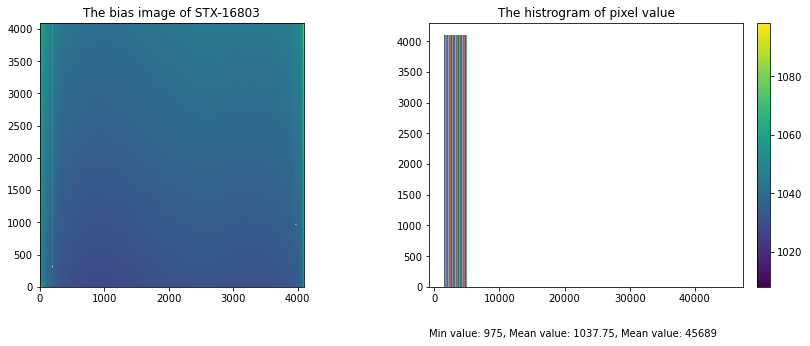

In [ ]:
hdul = fits.open(bias_fits[12])

fig, axs = plt.subplots(1, 2, figsize=(13, 6), sharex=False, sharey=False, gridspec_kw=None)

im1 = yvu.zimshow(axs[0], hdul[0].data)
im2 = axs[1].hist(hdul[0].data 
                    #histtype='step',
                    #50 
                    )

axs[0].set_title('The bias image of STX-16803')
axs[1].set_title('The histrogram of pixel value')

plt.annotate(f"Min value: {hdul[0].data.min()}, Mean value: {hdul[0].data.mean():.02f}, Mean value: {hdul[0].data.max()}", xy=(0, -50), xycoords='axes pixels')

plt.colorbar(im1, fraction=0.0455, pad=0.04)
plt.tight_layout(pad=5.0)

### DARK

In [ ]:
dark_fits = summary.loc[summary["IMAGETYP"] == "DARK"].copy()
dark_fits.reset_index(inplace=True)
dark_fits = dark_fits["file"]
print(type(dark_fits))
print(len(dark_fits))
print(dark_fits)

<class 'pandas.core.series.Series'>
20
0     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
1     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
2     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
3     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
4     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
5     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
6     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
7     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
8     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
9     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
10    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
11    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
12    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
13    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
14    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
15    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
16    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
17    R:\

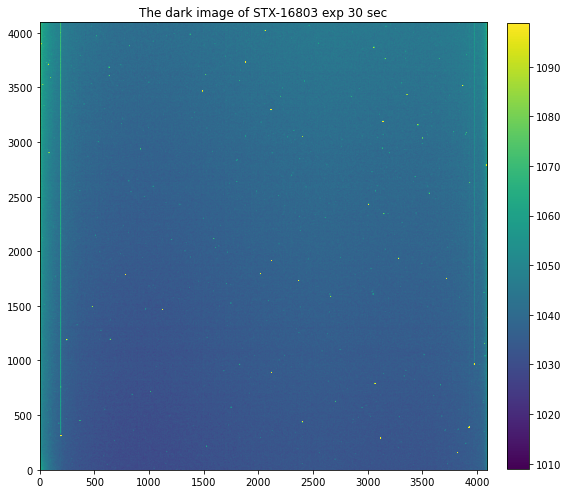

In [ ]:
hdul = fits.open(dark_fits[5])

fig, axs = plt.subplots(1, 1, figsize=(8, 8), sharex=False, sharey=False, gridspec_kw=None)
im = yvu.zimshow(axs, hdul[0].data)
axs.set_title('The dark image of STX-16803 exp 30 sec')
plt.colorbar(im, fraction=0.0455, pad=0.04)
plt.tight_layout()

C:\Users\Kiehyun\AppData\Local\Temp/ipykernel_20188/427932723.py:16: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().
  plt.colorbar(im1, fraction=0.0455, pad=0.04)


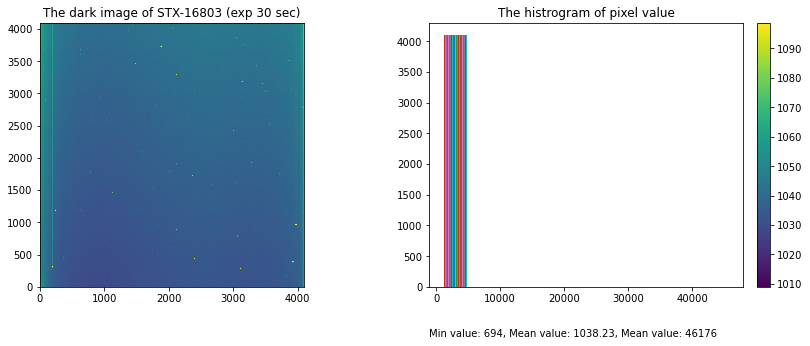

In [ ]:
hdul = fits.open(dark_fits[5])

fig, axs = plt.subplots(1, 2, figsize=(13, 6), sharex=False, sharey=False, gridspec_kw=None)

im1 = yvu.zimshow(axs[0], hdul[0].data)
im2 = axs[1].hist(hdul[0].data 
                    #histtype='step',
                    #50 
                    )

axs[0].set_title('The dark image of STX-16803 (exp 30 sec)')
axs[1].set_title('The histrogram of pixel value')

plt.annotate(f"Min value: {hdul[0].data.min()}, Mean value: {hdul[0].data.mean():.02f}, Mean value: {hdul[0].data.max()}", xy=(0, -50), xycoords='axes pixels')

plt.colorbar(im1, fraction=0.0455, pad=0.04)
plt.tight_layout(pad=5.0)

## Flat

In [ ]:
flat_fits = summary.loc[summary["IMAGETYP"] == "FLAT"].copy()
flat_fits.reset_index(inplace=True)
flat_fits = flat_fits["file"]
print(type(flat_fits))
print(len(flat_fits))
print(flat_fits)

<class 'pandas.core.series.Series'>
18
0     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
1     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
2     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
3     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
4     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
5     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
6     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
7     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
8     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
9     R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
10    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
11    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
12    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
13    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
14    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
15    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
16    R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...
17    R:\

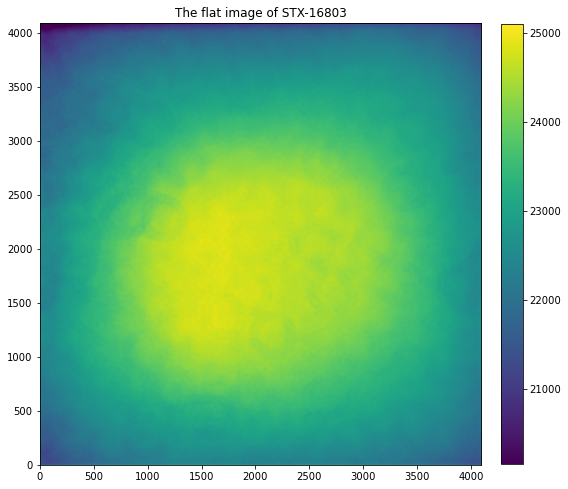

In [ ]:
hdul = fits.open(flat_fits[3])

fig, axs = plt.subplots(1, 1, figsize=(8, 8), sharex=False, sharey=False, gridspec_kw=None)
im = yvu.zimshow(axs, hdul[0].data)
axs.set_title('The flat image of STX-16803')
plt.colorbar(im, fraction=0.0455, pad=0.04)
plt.tight_layout()

C:\Users\Kiehyun\AppData\Local\Temp/ipykernel_20188/1202428641.py:14: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().
  plt.colorbar(im1, fraction=0.0455, pad=0.04)


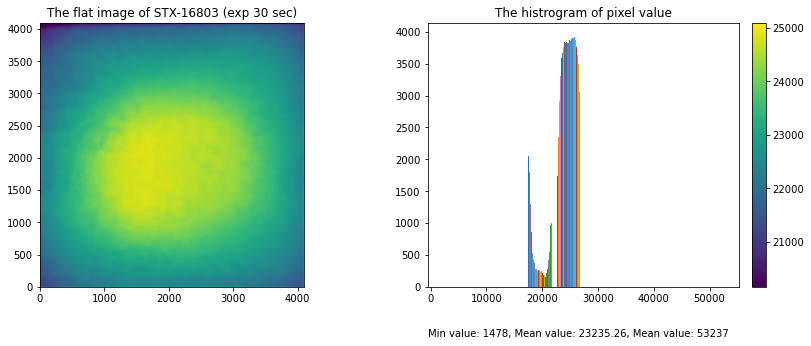

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(13, 6), sharex=False, sharey=False, gridspec_kw=None)

im1 = yvu.zimshow(axs[0], hdul[0].data)
im2 = axs[1].hist(hdul[0].data 
                    #histtype='step',
                    #50 
                    )

axs[0].set_title('The flat image of STX-16803 (exp 30 sec)')
axs[1].set_title('The histrogram of pixel value')

plt.annotate(f"Min value: {hdul[0].data.min()}, Mean value: {hdul[0].data.mean():.02f}, Mean value: {hdul[0].data.max()}", xy=(0, -50), xycoords='axes pixels')

plt.colorbar(im1, fraction=0.0455, pad=0.04)
plt.tight_layout(pad=5.0)

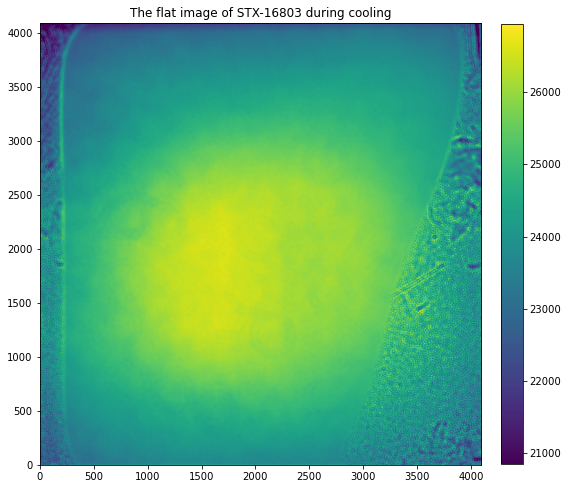

In [ ]:
hdul = fits.open(flat_fits[10])

fig, axs = plt.subplots(1, 1, figsize=(8, 8), sharex=False, sharey=False, gridspec_kw=None)
im = yvu.zimshow(axs, hdul[0].data)
axs.set_title('The flat image of STX-16803 during cooling')
plt.colorbar(im, fraction=0.0455, pad=0.04)
plt.tight_layout()

## Flat image

skyflat image

C:\Users\Kiehyun\AppData\Local\Temp/ipykernel_20188/1132229479.py:14: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().
  plt.colorbar(im1, fraction=0.0455, pad=0.04)


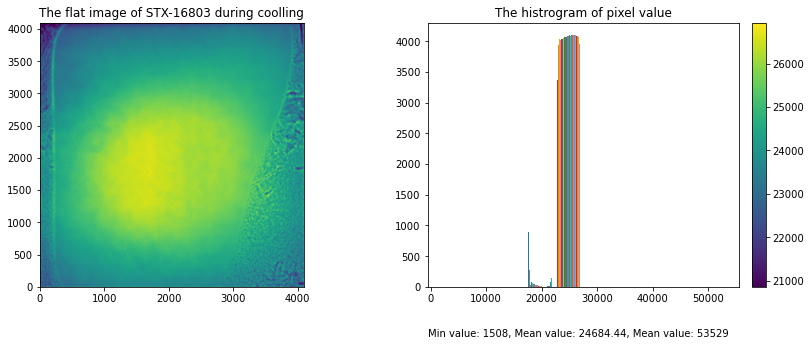

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(13, 6), sharex=False, sharey=False, gridspec_kw=None)

im1 = yvu.zimshow(axs[0], hdul[0].data)
im2 = axs[1].hist(hdul[0].data 
                    #histtype='step',
                    #50 
                    )

axs[0].set_title('The flat image of STX-16803 during coolling')
axs[1].set_title('The histrogram of pixel value')

plt.annotate(f"Min value: {hdul[0].data.min()}, Mean value: {hdul[0].data.mean():.02f}, Mean value: {hdul[0].data.max()}", xy=(0, -50), xycoords='axes pixels')

plt.colorbar(im1, fraction=0.0455, pad=0.04)
plt.tight_layout(pad=5.0)